# Explorar los despidos de 2026 con Python y SQL

**Por Nicolás Gómez · trabajoremoto.cl**

Una exploración reproducible de anuncios de despidos: qué razones ofrecen las fuentes, cómo se combinan y qué información falta. Incluye código, gráficos y consulta de evidencia. No modifica los datos de origen ni necesita otro artículo para interpretarse.

**Datos:** una colección curada a partir de Layoffs.fyi y fuentes adicionales. La base conserva 235 registros; esta exploración utiliza los 228 anuncios de enero–junio de 2026. Se excluyen cinco medidas históricas o de período y dos entradas de julio. No es un censo de todos los despidos.

**Recorrido:** cargar y comprobar → entender las tablas → contar razones → cruzar IA con otras razones → abrir evidencia → explorar funciones y datos faltantes.

La unidad es el **anuncio**, no una persona ni una empresa. Una razón atribuida no es una causa demostrada. La revisión externa llega al 17 de septiembre de 2026; ejecutar el notebook no actualiza esa cobertura.

Ejecuta **Run All** con un kernel Python que tenga `pandas` y `matplotlib`. SQLite forma parte de Python. Solo se necesita la exportación normalizada: las comprobaciones contrastan resultados calculados con pandas y SQL.

In [1]:
from pathlib import Path
import hashlib
import json
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Opcional: indica aquí la carpeta que contiene layoffs.sqlite y manifest.json.
DATA_DIR = None  # Ejemplo: Path("/ruta/a/normalized")
if DATA_DIR is None:
    candidates = [base / folder for base in [Path.cwd(), *Path.cwd().parents]
                  for folder in ["data/normalized", "normalized"]]
    DATA_DIR = next((p for p in candidates if (p / "layoffs.sqlite").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Coloca data/normalized junto al notebook o configura DATA_DIR con la ruta de la exportación")
DATA = Path(DATA_DIR)
manifest = json.loads((DATA / "manifest.json").read_text())
# Verifica que SQLite y CSV pertenecen a la exportación descrita en el manifest.
for name in ["layoffs.sqlite", "announcements.csv", "announcement_causes.csv"]:
    assert hashlib.sha256((DATA / name).read_bytes()).hexdigest() == manifest["files"][name], name

db = sqlite3.connect((DATA / "layoffs.sqlite").resolve().as_uri() + "?mode=ro", uri=True)
def sql(query, params=()):
    return pd.read_sql_query(query, db, params=params)

pd.set_option("display.max_colwidth", 110)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Cobertura externa:", manifest["coverage_snapshot"])
print("Última revisión de registros:", manifest["latest_record_review"])

Cobertura externa: 2026-09-17
Última revisión de registros: 2026-09-17


<a id="poblacion"></a>

## 1. ¿Qué estamos contando?

`records` conserva la base completa. La vista `announcements` selecciona anuncios fechados entre el 1 de enero y el 30 de junio de 2026. Usamos esa vista y sus relaciones `announcement_causes` y `announcement_functions` para mantener el mismo alcance en cada consulta.

Los siete registros excluidos siguen disponibles con su motivo. La exclusión de medidas históricas o de período evita mezclarlas con nuevos anuncios; no es una limpieza de duplicados.

In [2]:
announcements = sql("SELECT * FROM announcements")
reasons = sql("SELECT * FROM announcement_causes")
functions = sql("SELECT * FROM announcement_functions")
causes = sql("SELECT * FROM causes")
announcements["record_date"] = pd.to_datetime(announcements["record_date"])
announcements["laid_off"] = announcements["laid_off"].astype("Int64")
announcements["has_ai_reason"] = announcements["has_ai_reason"].astype(bool)

scope = pd.Series({
    "Registros internos": int(sql("SELECT COUNT(*) AS n FROM records").iloc[0, 0]),
    "Anuncios de enero–junio": len(announcements),
    "Etiquetas de empresa en los anuncios": announcements.company_id.nunique(),
    "Relaciones anuncio–razón": len(reasons),
    "Relaciones anuncio–función": len(functions),
}, name="Recuento")
display(scope.to_frame())
display(sql("SELECT * FROM excluded_records"))

,Recuento
Registros internos,235
Anuncios de enero–junio,228
Etiquetas de empresa en los anuncios,217
Relaciones anuncio–razón,304
Relaciones anuncio–función,116


,record_id,company_label,record_date,record_type,exclusion_reason
0,layoff-2026-001,Multiverse,2026-01-05,historical_report,not_new_announcement
1,layoff-2026-071,Dell,2026-03-16,annual_workforce_change,not_new_announcement
2,layoff-2026-105,GoCardless,2026-04-14,historical_report,not_new_announcement
3,layoff-2026-162,Microsoft (Xbox),2026-07-06,announcement,outside_2026_h1
4,layoff-2026-163,Microsoft (corporate),2026-07-06,announcement,outside_2026_h1
5,layoff-2026-180,Oracle,2026-06-23,annual_workforce_change,not_new_announcement
6,layoff-2026-226,SoundThinking,2026-03-31,historical_report,not_new_announcement


**Alternativa con CSV.** Es la misma tabla, con fechas y nulos tipados explícitamente. No hace falta deserializar JSON de las celdas. `workforce_fraction=0.1` significa 10%; una cifra desconocida permanece nula.

In [3]:
from_csv = pd.read_csv(DATA / "announcements.csv", parse_dates=["record_date"],
                       dtype={"laid_off": "Int64"})
assert set(from_csv.record_id) == set(announcements.record_id)
display(from_csv[["record_id", "company_label", "record_date", "laid_off",
                  "workforce_fraction", "review_status"]].head())

,record_id,company_label,record_date,laid_off,workforce_fraction,review_status
0,layoff-2026-002,Angi,2026-01-07,350,NaN,source_reviewed
1,layoff-2026-003,Foretellix,2026-01-08,29,0.18,source_reviewed
2,layoff-2026-004,Hailo,2026-01-08,30,0.10,source_reviewed
3,layoff-2026-005,Kaseya,2026-01-08,250,0.05,source_reviewed
4,layoff-2026-006,Tailwind Labs,2026-01-08,3,NaN,source_reviewed


<a id="uniones"></a>

## 2. ¿Qué ocurre al unir tablas?

Una unión anuncio–razón tiene varias filas para algunos anuncios. Esto es normal: el error sería interpretar cada fila como un anuncio nuevo o sumar sus puestos repetidamente. `validate="one_to_many"` comprueba la relación que esperamos.

Incluso antes de unir tablas, sumar puestos no garantiza un total de personas únicas: puede haber planes que se solapan, cifras aproximadas y ejecuciones pendientes.

In [4]:
joined = announcements[["record_id", "company_label", "laid_off"]].merge(
    reasons, on="record_id", how="left", validate="one_to_many")
display(pd.Series({"Filas tras el join": len(joined),
                   "Anuncios distintos tras el join": joined.record_id.nunique(),
                   "Anuncios originales": len(announcements)}, name="Recuento").to_frame())
assert joined.record_id.nunique() == len(announcements)
assert not reasons.duplicated(["record_id", "cause_code"]).any()

,Recuento
Filas tras el join,331
Anuncios distintos tras el join,228
Anuncios originales,228


<a id="razones"></a>

## 3. ¿Qué razones se repiten?

Se cuentan todas las razones atribuidas, incluidas las que no detallan el cambio. Las barras se solapan. Los códigos de categorías son estables para filtrar y agrupar; las etiquetas solo facilitan la lectura.

,anuncios
cause_code,
cost_cutting,45
organizational_consolidation,43
strategic_pivot,29
ai_productivity,24
ai_investment_reallocation,14
shutdown,14
ai_transition,13
operational_efficiency,11
unit_closure,11


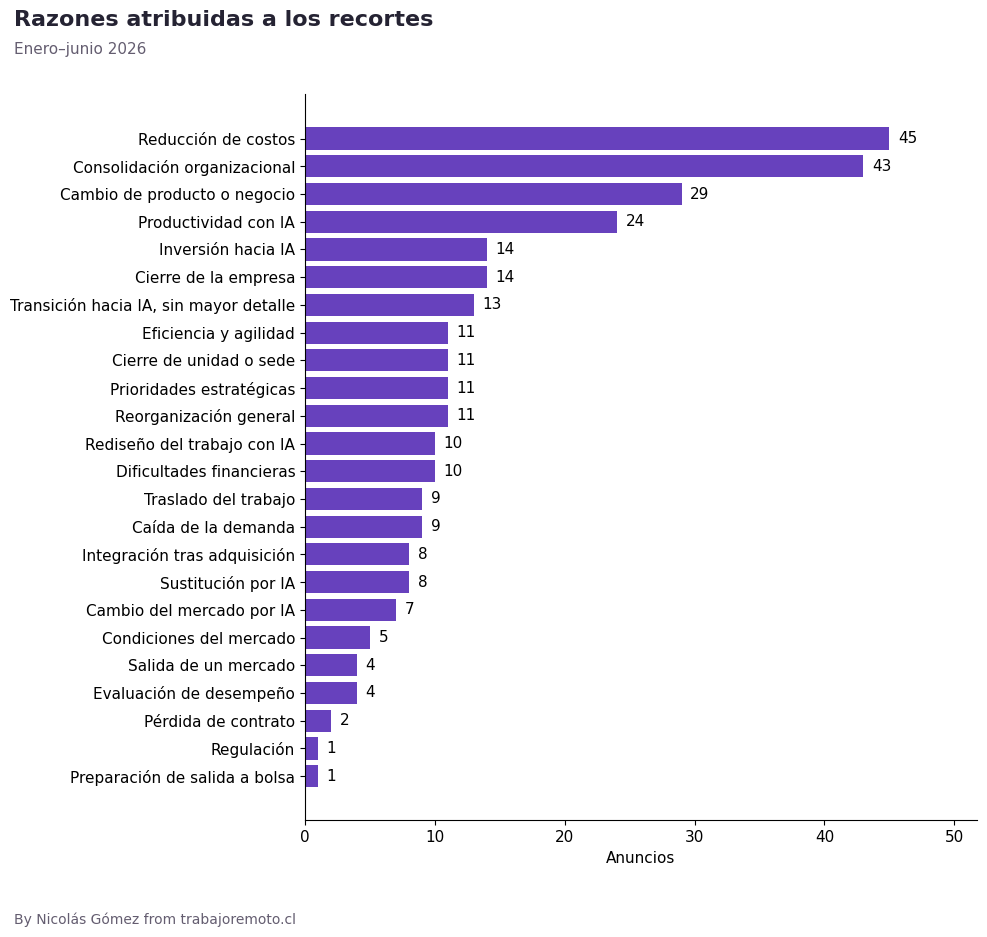

In [5]:
labels = {
 "cost_cutting":"Reducción de costos", "organizational_consolidation":"Consolidación organizacional",
 "strategic_pivot":"Cambio de producto o negocio", "ai_productivity":"Productividad con IA",
 "ai_investment_reallocation":"Inversión hacia IA", "shutdown":"Cierre de la empresa",
 "ai_transition":"Transición hacia IA, sin mayor detalle", "organizational_realignment":"Reorganización general",
 "strategic_priorities":"Prioridades estratégicas", "unit_closure":"Cierre de unidad o sede",
 "operational_efficiency":"Eficiencia y agilidad", "financial_distress":"Dificultades financieras",
 "ai_work_redesign":"Rediseño del trabajo con IA", "work_relocation":"Traslado del trabajo",
 "demand_decline":"Caída de la demanda", "m_and_a":"Integración tras adquisición",
 "ai_substitution":"Sustitución por IA", "ai_market_disruption":"Cambio del mercado por IA",
 "market_conditions":"Condiciones del mercado", "performance_cull":"Evaluación de desempeño",
 "market_exit":"Salida de un mercado", "lost_contract":"Pérdida de contrato",
 "regulatory":"Regulación", "ipo_prep":"Preparación de salida a bolsa",
}
counts = reasons.groupby("cause_code").record_id.nunique().sort_values(ascending=False)
display(counts.rename("anuncios").to_frame())

def bar_chart(series, title, xlabel="Anuncios", color="#6741bd"):
    height = max(4, len(series) * .36 + .8)
    fig, ax = plt.subplots(figsize=(10, height))
    ax.barh(series.index, series.values, color=color)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, max(series.values) * 1.15)
    for i, value in enumerate(series.values):
        ax.text(value + max(series.values) * .015, i, str(int(value)), va="center")
    # El título pertenece a la figura completa, no solo al área de barras.
    heading, _, subtitle = title.partition(" · ")
    fig.tight_layout(rect=(0, .6 / height, 1, 1 - .8 / height))
    fig.text(.02, 1 - .12 / height, heading, ha="left", va="top",
             fontsize=16, fontweight="bold", color="#252333")
    if subtitle:
        fig.text(.02, 1 - .44 / height, subtitle.capitalize(), ha="left", va="top",
                 fontsize=11, color="#645d70")
    fig.text(.02, .15 / height, "By Nicolás Gómez from trabajoremoto.cl",
             ha="left", va="bottom", color="#645d70", fontsize=10)
    plt.show()
    return fig

fig = bar_chart(counts.rename(index=labels), "Razones atribuidas a los recortes · enero–junio 2026")
# Opcional: fig.savefig("razones.png", dpi=180, bbox_inches="tight")

<a id="grupos"></a>

## 4. ¿Cuántos anuncios vinculan IA con otras razones?

Construimos una matriz binaria anuncio–razón. Reindexamos con **todos** los anuncios para conservar también los que no tienen una razón clasificable. No tener una razón de IA registrada no demuestra ausencia de influencia de IA.

,anuncios
IA y otra razón,48
Solo razones de IA registradas,24
Solo otras razones registradas,129
Sin explicación clasificable,27


72 anuncios con IA; 48 también tienen otra razón.
79 anuncios contienen varias razones.


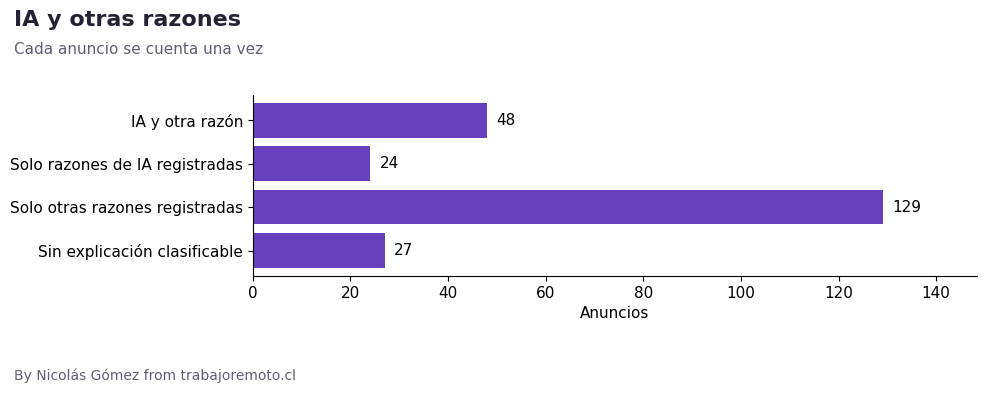

In [6]:
presence = pd.crosstab(reasons.record_id, reasons.cause_code).reindex(
    announcements.record_id, fill_value=0).astype(bool)
ai_codes = causes.loc[causes.is_ai.eq(1), "cause_code"].tolist()
other_codes = causes.loc[causes.is_ai.eq(0), "cause_code"].tolist()
has_ai = presence[ai_codes].any(axis=1)
has_other = presence[other_codes].any(axis=1)
groups = pd.Series({
    "IA y otra razón": int((has_ai & has_other).sum()),
    "Solo razones de IA registradas": int((has_ai & ~has_other).sum()),
    "Solo otras razones registradas": int((~has_ai & has_other).sum()),
    "Sin explicación clasificable": int((~has_ai & ~has_other).sum()),
})
display(groups.rename("anuncios").to_frame())
assert groups.sum() == len(announcements)
print(f"{has_ai.sum()} anuncios con IA; {(has_ai & has_other).sum()} también tienen otra razón.")
print(f"{presence.sum(axis=1).gt(1).sum()} anuncios contienen varias razones.")
_ = bar_chart(groups, "IA y otras razones · cada anuncio se cuenta una vez")

<a id="razones-con-ia"></a>

## ¿Qué otras razones acompañan a cualquier explicación de IA?

Cada barra cuenta anuncios únicos con esa razón y al menos una razón de IA. Un anuncio con dos razones de IA se cuenta una sola vez por barra. Por eso no sumamos las celdas de la matriz de cruces. Las barras se solapan entre sí: 48 de los 72 anuncios vinculados con IA tienen otras razones.

,razon,anuncios
0,Reducción de costos,19
1,Consolidación organizacional,18
2,Cambio de producto o negocio,8
3,Traslado del trabajo,4
4,Eficiencia y agilidad,3
5,Integración tras adquisición,2
6,Condiciones del mercado,2
7,Caída de la demanda,1
8,Dificultades financieras,1
9,Preparación de salida a bolsa,1


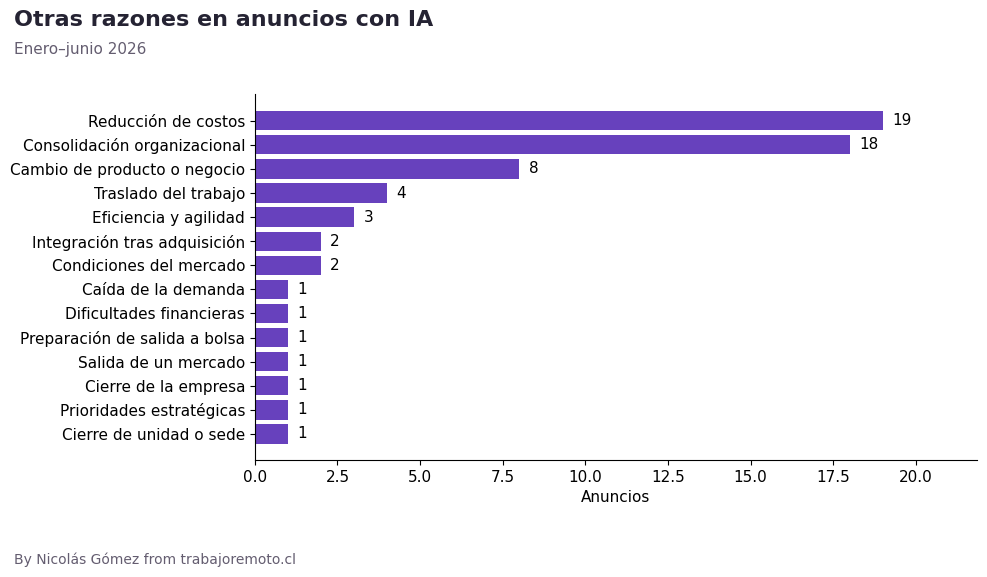

In [7]:
other_with_ai = sql("""SELECT c.cause_code, COUNT(DISTINCT c.record_id) AS anuncios
FROM announcement_causes c JOIN causes t USING(cause_code)
WHERE t.is_ai=0 AND EXISTS (
 SELECT 1 FROM announcement_causes ai JOIN causes at ON at.cause_code=ai.cause_code
 WHERE ai.record_id=c.record_id AND at.is_ai=1)
GROUP BY c.cause_code ORDER BY anuncios DESC,c.cause_code""")
any_ai = presence[ai_codes].any(axis=1)
pandas_counts = presence.loc[any_ai,other_codes].sum()
assert other_with_ai.set_index('cause_code').anuncios.to_dict()==pandas_counts[pandas_counts.gt(0)].astype(int).to_dict()
assert int((any_ai & presence[other_codes].any(axis=1)).sum())==48
assert int(any_ai.sum())==72
display(other_with_ai.assign(razon=other_with_ai.cause_code.map(labels))[['razon','anuncios']])
fig = bar_chart(other_with_ai.set_index('cause_code').anuncios.rename(index=labels),
                'Otras razones en anuncios con IA · enero–junio 2026')
plt.show()


<a id="cruces"></a>

## 5. ¿Qué cruces de IA son más frecuentes?

El producto matricial cuenta anuncios que tienen las dos razones. Convertimos los booleanos a enteros antes de multiplicar. El ranking muestra cinco posiciones e incluye todos los empates en la quinta; no son grupos mutuamente excluyentes.

,cruce,anuncios
0,Productividad con IA + Reducción de costos,12
1,Productividad con IA + Consolidación organizacional,8
2,Inversión hacia IA + Reducción de costos,5
3,Cambio del mercado por IA + Cambio de producto o negocio,4
4,Inversión hacia IA + Consolidación organizacional,3
5,Productividad con IA + Cambio de producto o negocio,3
6,"Transición hacia IA, sin mayor detalle + Eficiencia y agilidad",3
7,Rediseño del trabajo con IA + Reducción de costos,3


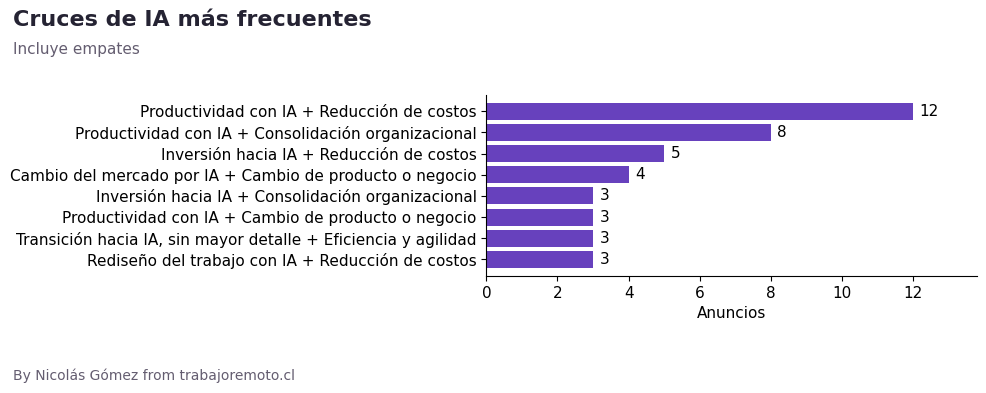

In [8]:
cross = presence[ai_codes].astype(int).T @ presence[other_codes].astype(int)
pairs = cross.rename_axis(index="ai_reason", columns="other_reason").stack().rename("anuncios").reset_index()
pairs = pairs.loc[pairs.anuncios.gt(0)].sort_values(
    ["anuncios", "ai_reason", "other_reason"], ascending=[False, True, True]).reset_index(drop=True)
cutoff = pairs.iloc[min(4, len(pairs)-1)].anuncios
top = pairs.loc[pairs.anuncios.ge(cutoff)].copy()
top["cruce"] = top.ai_reason.map(labels) + " + " + top.other_reason.map(labels)
display(top[["cruce", "anuncios"]])
_ = bar_chart(top.set_index("cruce").anuncios, "Cruces de IA más frecuentes · incluye empates")

# Mismo cálculo mediante SQL: 12 en el snapshot incluido.
check = sql("""SELECT COUNT(DISTINCT a.record_id) AS n
FROM announcement_causes a JOIN announcement_causes b USING(record_id)
WHERE a.cause_code=? AND b.cause_code=?""", ("ai_productivity", "cost_cutting"))
assert int(check.iloc[0, 0]) == int(cross.loc["ai_productivity", "cost_cutting"])

<a id="evidencia"></a>

## 6. ¿Qué evidencia hay detrás de una cifra?

Cambiar estos dos códigos permite inspeccionar cualquier cruce. El resultado conserva quién atribuye cada razón, a qué alcance y con qué fuente. Las relaciones se hacen con validación; la fuente se une desde la **atribución**, no desde el enlace general del anuncio.

In [9]:
AI_REASON = "ai_productivity"
OTHER_REASON = "cost_cutting"
selected_ids = presence.index[presence[AI_REASON] & presence[OTHER_REASON]]
evidence = reasons.loc[reasons.record_id.isin(selected_ids) & reasons.cause_code.isin([AI_REASON, OTHER_REASON])].merge(
    announcements[["record_id", "company_label", "record_date"]], on="record_id", validate="many_to_one"
).merge(sql("SELECT * FROM sources"), on="source_id", how="left", validate="many_to_one")
display(evidence[["company_label", "record_date", "cause_code", "attribution", "scope", "summary", "url"]]
        .sort_values(["company_label", "cause_code"]).reset_index(drop=True))

,company_label,record_date,cause_code,attribution,scope,summary,url
0,Angi,2026-01-07,ai_productivity,company_stated,event,The filing attributes the reduction in part to AI-driven efficiency improvements.,https://www.sec.gov/Archives/edgar/data/1705110/000170511026000005/angi-20260107.htm
1,Angi,2026-01-07,cost_cutting,company_stated,event,Company targets lower operating expenses and annual savings.,https://www.sec.gov/Archives/edgar/data/1705110/000170511026000005/angi-20260107.htm
2,C3.ai,2026-02-25,ai_productivity,company_stated,event,The CEO cites AI-driven productivity gains across functions as part of the explanation for reducing headco...,https://www.cio.com/article/4138095/c3-ai-slashes-26-of-its-workforce-ceo-attributes-the-move-in-part-to-a...
3,C3.ai,2026-02-25,cost_cutting,press_reported,event,CEO Stephen Ehikian said the cost structure was 'simply too high' after aggressive 2024-25 hiring outpaced...,https://www.cio.com/article/4138095/c3-ai-slashes-26-of-its-workforce-ceo-attributes-the-move-in-part-to-a...
4,Coinbase,2026-05-05,ai_productivity,company_stated,event,"The CEO links the reduction to AI-enabled work by smaller teams, with examples from engineering and other ...",https://www.coinbase.com/blog/building-a-leaner-and-faster-coinbase
5,Coinbase,2026-05-05,cost_cutting,press_reported,event,Adjusting cost structure amid crypto market downturn while leveraging AI tools so smaller teams can do more.,https://www.coinbase.com/blog/building-a-leaner-and-faster-coinbase
6,Gemini,2026-03-20,ai_productivity,company_stated,year_to_date,Shareholder letter links its smaller workforce to AI-enabled output across engineering and other work.,https://last10k.com/sec-filings/gemi/0002055592-26-000023.htm
7,Gemini,2026-03-20,cost_cutting,company_stated,year_to_date,Company targets a lower operating cost base.,https://last10k.com/sec-filings/gemi/0002055592-26-000023.htm
8,Gloo,2026-01-29,ai_productivity,company_stated,event,CEO links workforce reductions to AI-enabled operating efficiencies.,https://investors.gloo.com/static-files/6a6cee16-3074-4288-83a4-ce6487c4267f
9,Gloo,2026-01-29,cost_cutting,company_stated,event,The cuts and resource reallocation support the stated profitability target.,https://investors.gloo.com/static-files/6a6cee16-3074-4288-83a4-ce6487c4267f


<a id="cierres"></a>

## 7. ¿Los anuncios que citan dificultades financieras también anuncian un cierre?

Un recorte puede intentar mantener una empresa en funcionamiento o formar parte de su cierre. Para distinguir ambas situaciones, cruzamos dos categorías: **dificultades financieras** y **cierre de la empresa**.

Primero contamos tres grupos que no se solapan: anuncios que contienen las dos categorías, anuncios que solo contienen la primera y anuncios que solo contienen la segunda. «Solo» se refiere a estas dos categorías; pueden tener otras razones registradas.

La pregunta se limita a lo que dicen los anuncios de esta colección. No estamos siguiendo a empresas con problemas financieros para averiguar cuántas terminan cerrando.

In [10]:
financial = presence["financial_distress"]
closure = presence["shutdown"]
both = int((financial & closure).sum())
financial_only = int((financial & ~closure).sum())
closure_only = int((~financial & closure).sum())

display(pd.DataFrame({
    "Qué aparece en el anuncio": [
        "Dificultades financieras y cierre",
        "Dificultades financieras, sin cierre registrado",
        "Cierre, sin dificultades financieras registradas",
    ],
    "Anuncios": [both, financial_only, closure_only],
}).set_index("Qué aparece en el anuncio"))

from IPython.display import Markdown
n_financial = int(financial.sum())
n_closure = int(closure.sum())
display(Markdown(
    f"**Respuesta: {both} de los {n_financial} anuncios que citan dificultades "
    "financieras también anuncian un cierre.** El resto cita "
    "dificultades financieras sin registrar un cierre.\n\n"
    f"Si empezamos por todos los cierres, la pregunta cambia: hay **{n_closure} anuncios "
    f"de cierre**, y **{both} citan dificultades financieras**. En los otros "
    f"{closure_only}, esa razón no está registrada; eso no demuestra que no hubiera "
    "problemas financieros.\n\n"
    f"**Son los mismos {both} anuncios vistos desde dos grupos distintos:** "
    f"{both} de {n_financial} al partir de las dificultades financieras, "
    f"y {both} de {n_closure} al partir de los cierres. "
    "No son dos hallazgos independientes ni una estimación del riesgo de cierre."
))

,Anuncios
Qué aparece en el anuncio,
Dificultades financieras y cierre,9
"Dificultades financieras, sin cierre registrado",1
"Cierre, sin dificultades financieras registradas",5


**Respuesta: 9 de los 10 anuncios que citan dificultades financieras también anuncian un cierre.** El resto cita dificultades financieras sin registrar un cierre.

Si empezamos por todos los cierres, la pregunta cambia: hay **14 anuncios de cierre**, y **9 citan dificultades financieras**. En los otros 5, esa razón no está registrada; eso no demuestra que no hubiera problemas financieros.

**Son los mismos 9 anuncios vistos desde dos grupos distintos:** 9 de 10 al partir de las dificultades financieras, y 9 de 14 al partir de los cierres. No son dos hallazgos independientes ni una estimación del riesgo de cierre.

<a id="funciones"></a>

## 8. ¿Qué trabajo se recorta y cuánto desconocemos?

Las funciones son una relación independiente de las razones. No deducimos ingeniería a partir de una unidad llamada «Cloud», ni sustitución por IA a partir de que se recorte soporte. No podemos ordenar profesiones por riesgo: faltan denominadores de empleo y la cobertura de funciones es incompleta.

In [11]:
function_rows = functions.merge(announcements[["record_id", "has_ai_reason"]],
                                on="record_id", validate="many_to_one")
function_counts = function_rows.groupby("function_code").agg(
    anuncios=("record_id", "nunique"), con_ia=("has_ai_reason", "sum")
).sort_values("anuncios", ascending=False)
function_counts = function_counts.join(sql("SELECT * FROM functions").set_index("function_code"))
display(function_counts[["label_es", "anuncios", "con_ia"]])
known_ids = set(functions.record_id)
print("Anuncios con funciones identificadas:", len(known_ids))
print("Anuncios con IA sin función identificada:",
      int((announcements.has_ai_reason & ~announcements.record_id.isin(known_ids)).sum()))

missing = announcements[["industry", "funding_stage", "laid_off", "workforce_fraction", "raised_millions"]].isna().sum()
display(missing.rename("sin_dato").to_frame())
display(announcements.groupby("review_status").size().rename("anuncios").to_frame())

,label_es,anuncios,con_ia
function_code,,,
engineering,Ingeniería e I+D,31,8
product_design,Producto y diseño,19,8
marketing,Marketing,13,6
sales,Ventas y alianzas,11,4
operations,Operaciones y prestación de servicios,10,4
support,Soporte y atención al cliente,8,3
content,Contenido y docencia,6,1
corporate,"Administración, finanzas y legal",5,1
it_security,TI y ciberseguridad,4,0


Anuncios con funciones identificadas: 60
Anuncios con IA sin función identificada: 57


,sin_dato
industry,66
funding_stage,88
laid_off,82
workforce_fraction,105
raised_millions,94


,anuncios
review_status,
partial,14
source_reviewed,212
unavailable,2


<a id="comprobaciones"></a>

## 9. ¿Son consistentes los cálculos?

Contrastamos las frecuencias y todos los cruces con dos métodos: operaciones sobre la matriz binaria en pandas y consultas SQL sobre las relaciones. También verificamos unicidad y cobertura. No se necesitan resultados precalculados de otro análisis.

Si estas comprobaciones pasan, los cálculos coinciden; eso no verifica la veracidad de las explicaciones de las fuentes ni corrige vacíos de cobertura.

In [12]:
assert len(announcements) == manifest["tables"]["announcements"]["rows"]
assert announcements.record_id.is_unique
assert len(presence) == len(announcements)
assert int(has_ai.sum()) == int(announcements.has_ai_reason.sum())
assert counts.to_dict() == sql("""SELECT cause_code, COUNT(DISTINCT record_id) AS n
FROM announcement_causes GROUP BY cause_code""").set_index("cause_code").n.to_dict()

# Compara TODOS los pares, no solo los seleccionados para los gráficos.
sql_pairs = sql("""SELECT a.cause_code AS reason_a, b.cause_code AS reason_b,
COUNT(DISTINCT a.record_id) AS n
FROM announcement_causes a JOIN announcement_causes b USING(record_id)
WHERE a.cause_code < b.cause_code
GROUP BY a.cause_code, b.cause_code""")
all_cross = presence.astype(int).T @ presence.astype(int)
pandas_pairs = {(a, b): int(all_cross.loc[a, b])
                for a in all_cross.index for b in all_cross.columns
                if a < b and all_cross.loc[a, b] > 0}
sql_pair_counts = {(r.reason_a, r.reason_b): int(r.n)
                   for r in sql_pairs.itertuples(index=False)}
assert pandas_pairs == sql_pair_counts
print(f"Comprobaciones correctas: {len(announcements)} anuncios, "
      f"{len(counts)} razones y {len(sql_pairs)} cruces verificados con pandas y SQL.")


Comprobaciones correctas: 228 anuncios, 24 razones y 61 cruces verificados con pandas y SQL.


<a id="atribuciones"></a>

## 10. ¿Quién vincula los recortes con IA?

Contamos anuncios distintos por razón y procedencia. Una declaración empresarial es una atribución, no una verificación de productividad. La suma entre categorías puede contar el mismo anuncio varias veces.

In [13]:
ai_rows = reasons[reasons.cause_code.isin(ai_codes)]
display(pd.crosstab(ai_rows.cause_code, ai_rows.attribution))
display(ai_rows.groupby('cause_code').record_id.nunique().rename('Anuncios'))
multi_ai = ai_rows.groupby('record_id').size().loc[lambda x: x > 1]
display(announcements.set_index('record_id').loc[multi_ai.index, ['company_label', 'record_date']])
print('Asignaciones de IA:', len(ai_rows), 'en', ai_rows.record_id.nunique(), 'anuncios')
print('Productividad / sustitución:', (presence.ai_productivity.sum() / presence.ai_substitution.sum()))
# Todos los pares, también los que no incluyen IA.
from itertools import combinations
all_pairs = pd.DataFrame([(a,b,int((presence[a] & presence[b]).sum()))
                         for a,b in combinations(presence.columns,2)],
                        columns=['razon_1','razon_2','anuncios'])
display(all_pairs.sort_values('anuncios',ascending=False).head(12))

attribution,company_stated,press_reported,reported_inference,worker_reported
cause_code,,,,
ai_investment_reallocation,12,2,0,0
ai_market_disruption,7,0,0,0
ai_productivity,22,1,1,0
ai_substitution,6,0,1,1
ai_transition,10,2,0,1
ai_work_redesign,8,2,0,0


cause_code
ai_investment_reallocation    14
ai_market_disruption           7
ai_productivity               24
ai_substitution                8
ai_transition                 13
ai_work_redesign              10
Name: Anuncios, dtype: int64

,company_label,record_date
record_id,,
layoff-2026-057,Zap Africa,2026-02-28
layoff-2026-107,Productboard,2026-04-15
layoff-2026-185,Lastminute,2026-06-17
layoff-2026-213,Rapyd,2026-05-28


Asignaciones de IA: 76 en 72 anuncios
Productividad / sustitución: 3.0


,razon_1,razon_2,anuncios
131,cost_cutting,organizational_consolidation,13
48,ai_productivity,cost_cutting,12
166,financial_distress,shutdown,9
57,ai_productivity,organizational_consolidation,8
5,ai_investment_reallocation,cost_cutting,5
41,ai_market_disruption,strategic_pivot,4
136,cost_cutting,strategic_pivot,4
95,ai_transition,operational_efficiency,3
123,cost_cutting,demand_decline,3
14,ai_investment_reallocation,organizational_consolidation,3


<a id="negaciones"></a>

## 11. ¿Qué se niega al negar un vínculo con IA?

La tabla muestra el objeto de la negación y su fuente. Contamos registros, no frases. Filtramos declaraciones de la empresa y anuncios del semestre; conservamos las fuentes anónimas para inspección. La recopilación no fue uniforme: no permite comparar la propensión a negar entre empresas cotizadas y privadas.

In [14]:
denials = sql("""SELECT d.*, a.company_label, a.record_date, a.funding_stage, s.url
FROM denials d JOIN announcements a USING(record_id)
LEFT JOIN sources s USING(source_id)""")
display(denials)
company_denials = denials[denials.speaker.eq('company')].drop_duplicates('record_id')
ids = company_denials.record_id
print('Anuncios con negación empresarial:', len(ids))
print('También atribuyen inversión en IA:', int(presence.loc[ids,'ai_investment_reallocation'].sum()))
display(company_denials.funding_stage.fillna('Desconocida').value_counts())

,denial_id,record_id,target,speaker,summary,source_id,company_label,record_date,funding_stage,url
0,layoff-2026-018_denials_0,layoff-2026-018,replacement,company,Denies replacing people with AI while describing AI-related reinvestment.,src_4828391f332e6f02a96d,Autodesk,2026-01-22,Post-IPO,https://adsknews.autodesk.com/en/news/012226-employee-message/
1,layoff-2026-067_denials_0,layoff-2026-067,replacement,company,Rejects direct replacement framing while funding AI and enterprise sales.,src_bbefc935918809022f3d,Atlassian,2026-03-11,Post-IPO,https://www.atlassian.com/blog/company-news/atlassian-team-update-march-2026
2,layoff-2026-077_denials_0,layoff-2026-077,all_ai,company,Company explicitly says the layoffs are unrelated to AI.,src_9513906047389ea1d637,Epic Games,2026-03-24,None,https://www.epicgames.com/site/en-US/news/todays-layoffs
3,layoff-2026-149_denials_0,layoff-2026-149,replacement,anonymous_source,An anonymous source rejects AI automation as the cause; this is not an official denial.,src_10964fc555ea7a4fcb0f,LinkedIn,2026-05-13,Acquired,https://www.hcamag.com/us/news/general/linkedin-cuts-5-of-staff-despite-record-revenue-reuters-reports/575160
4,layoff-2026-155_denials_0,layoff-2026-155,all_ai,company,CEO denies an AI cause.,src_f2b6fb6ddc60a115002a,Intuit,2026-05-20,Post-IPO,https://www.indiatoday.in/jobs/story/software-maker-intuit-to-cut-3000-jobs-ceo-says-layoff-has-nothing-to...
5,layoff-2026-159_denials_0,layoff-2026-159,ai_optimization,company,"CEO denies AI optimization or cost cutting as the purpose, while naming AI reinvestment.",src_64ae35e88aaefe95db70,GitLab,2026-06-03,Post-IPO,https://about.gitlab.com/blog/gitlab-act-2/
6,layoff-2026-205_denials_0,layoff-2026-205,ai_cause_broadly,company,Company says these cuts did not result from AI.,src_b344c4c6792b172edfe5,Uber,2026-06-03,Post-IPO,https://www.cnbc.com/2026/06/03/uber-layoffs-people-division-ai.html
7,layoff-2026-221_denials_0,layoff-2026-221,ai_cause_broadly,anonymous_source,Unnamed TrendAI source says the R&D closure is not due to AI.,src_5333ae047537a0071339,Trend Micro,2026-05-12,None,https://www.itnews.com.au/news/trend-micros-enterprise-unit-shuts-sydney-engineering-team-625788


Anuncios con negación empresarial: 6
También atribuyen inversión en IA: 3


funding_stage
Post-IPO       5
Desconocida    1
Name: count, dtype: int64

<a id="casos"></a>

## 12. ¿Qué respalda los ejemplos concretos?

Cada fila es una explicación codificada, con autoría, alcance, resumen y enlace original. El resumen es trabajo de clasificación, no una transcripción ni una prueba independiente. Para comprobar una cita o interpretar un caso hay que abrir su fuente; ejecutar Python no vuelve verdadera la declaración.

Mostramos todas las explicaciones de los ejemplos, incluso cuando contradicen una lectura de «solo IA». Optimove permite examinar transición; Block y Snap, productividad; Atlassian, Autodesk y GitLab, inversión; Tailwind Labs, Productboard y Yupp, cambios de negocio; Salesforce, la inferencia externa; Covrzy y Rec Room, cierre. La consulta es editable.

In [15]:
case_names = ['Optimove','Block','Snap','LSports','Atlassian','Autodesk','GitLab',
              'Tailwind Labs','Productboard','Yupp','Salesforce','Zencity','Covrzy','Rec Room']
case_rows = sql("""SELECT a.record_id,a.company_label,a.record_date,c.cause_code,
c.attribution,c.scope,c.summary,s.url FROM announcements a
JOIN announcement_causes c USING(record_id) LEFT JOIN sources s ON s.source_id=c.source_id
ORDER BY a.company_label,a.record_date,c.cause_code""")
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(case_rows[case_rows.company_label.isin(case_names)])
print('Etiquetas solicitadas sin coincidencia:', sorted(set(case_names)-set(case_rows.company_label)))

,record_id,company_label,record_date,cause_code,attribution,scope,summary,url
28,layoff-2026-067,Atlassian,2026-03-11,ai_investment_reallocation,company_stated,event,The CEO says the staffing reduction will self-fund further investment in AI and enterprise sales.,https://www.atlassian.com/blog/company-news/atlassian-team-update-march-2026
29,layoff-2026-067,Atlassian,2026-03-11,cost_cutting,company_stated,event,The CEO links the reduction to improving the financial profile and accelerating sustained profitability.,https://www.atlassian.com/blog/company-news/atlassian-team-update-march-2026
30,layoff-2026-018,Autodesk,2026-01-22,ai_investment_reallocation,company_stated,event,"The CEO lists reinvestment in AI, platform and industry-cloud capabilities among the drivers of the reduction; completing the go-to-market transformation is the primary driver.",https://adsknews.autodesk.com/en/news/012226-employee-message/
31,layoff-2026-018,Autodesk,2026-01-22,organizational_consolidation,press_reported,event,"The cuts, mainly in customer-facing sales, complete a multi-year go-to-market transformation.",https://adsknews.autodesk.com/en/news/012226-employee-message/
36,layoff-2026-054,Block,2026-02-26,ai_productivity,company_stated,event,"The shareholder letter links the reduction to operating with a smaller team using intelligence tools, citing internal experience of increased output.",https://www.sec.gov/Archives/edgar/data/1512673/000119312526076557/d108590dex991.htm
53,layoff-2026-084,Covrzy,2026-03-31,financial_distress,company_stated,event,Founder describes failed funding/acquisition options preceding closure.,https://inc42.com/buzz/antler-backed-covrzy-shuts-down-due-to-cash-crunch/
54,layoff-2026-084,Covrzy,2026-03-31,shutdown,company_stated,event,Founder describes failed funding/acquisition options preceding closure.,https://inc42.com/buzz/antler-backed-covrzy-shuts-down-due-to-cash-crunch/
105,layoff-2026-159,GitLab,2026-06-03,ai_investment_reallocation,company_stated,announced_plan,Company plans to reinvest most savings into its agentic product and technology strategy.,https://about.gitlab.com/blog/gitlab-act-2/
106,layoff-2026-159,GitLab,2026-06-03,organizational_consolidation,company_stated,announced_plan,Company reduces layers and handoffs.,https://about.gitlab.com/blog/gitlab-act-2/
107,layoff-2026-159,GitLab,2026-06-03,work_relocation,company_stated,announced_plan,Company reduces its employment-country footprint while continuing customer service and offering some staff relocation.,https://about.gitlab.com/blog/gitlab-act-2/


Etiquetas solicitadas sin coincidencia: []


<a id="oracle"></a>

## 13. ¿El documento de una empresa explica un anuncio concreto?

Oracle permite separar tres unidades: el anuncio de marzo, el contexto del plan empresarial y la variación neta anual. Recuperamos también registros excluidos del análisis de anuncios. La reducción neta anual de 21.000 empleados no representa despidos brutos; los pasajes sobre IA del plan no distribuyen los puestos de marzo entre causas.

In [16]:
oracle = sql("""SELECT r.*, c.company_label FROM records r JOIN companies c USING(company_id)
WHERE c.company_label='Oracle'""")
display(oracle[['record_id','record_date','record_type','in_report','exclusion_reason','review_note']])
for table in ['record_causes','context','workforce_metrics']:
    print(table)
    detail = sql(f"SELECT t.*,s.url FROM {table} t LEFT JOIN sources s USING(source_id)")
    with pd.option_context('display.max_colwidth',None):
        display(detail[detail.record_id.isin(oracle.record_id)])

,record_id,record_date,record_type,in_report,exclusion_reason,review_note
0,layoff-2026-086,2026-03-31,announcement,1,None,The March termination email attributes role elimination to a broader organizational change following a rev...
1,layoff-2026-180,2026-06-23,annual_workforce_change,0,not_new_announcement,"Annual net workforce decrease, not a new June layoff round. Filing acknowledges AI-related reductions with..."


record_causes


,record_id,cause_code,attribution,scope,summary,source_id,evidence_access,url
114,layoff-2026-086,organizational_realignment,company_stated,event,The March termination email attributes role elimination to a broader organizational change following a review of business needs. It does not specify an AI mechanism.,src_9f6d3041c6dac06e7f91,full,https://www.moneycontrol.com/news/trends/full-text-of-the-email-oracle-sent-to-30-000-laid-off-employees-at-6-am-13876386.html


context


,context_id,record_id,kind,summary,source_id,url
16,layoff-2026-086_context_0,layoff-2026-086,broader_plan,FY2026 10-K Risk Factors acknowledges past AI-related reductions; Note 7 includes AI efficiencies in a broader plan. Neither allocates the March cuts or an AI headcount.,src_399ce87c8e72f98c2a3a,https://d1f19qmytqk9eo.cloudfront.net/edgar0105/2026/06/22/1341439/000119312526277521/document/orcl-20260531.htm
32,layoff-2026-180_context_0,layoff-2026-180,broader_plan_ai,Annual filing acknowledges AI-related reductions and AI integration in the broader efficiency plan. It does not allocate the net workforce change or March cuts to AI.,src_a74c98c112d8219e917c,https://www.cnbc.com/2026/06/23/oracle-ai-job-cuts-layoffs-21000.html


workforce_metrics


,record_id,value,metric,period,source_min,source_max,note,source_id,url
4,layoff-2026-086,21000.0,net_workforce_reduction,FY ended May 2026,NaN,NaN,None,src_399ce87c8e72f98c2a3a,https://d1f19qmytqk9eo.cloudfront.net/edgar0105/2026/06/22/1341439/000119312526277521/document/orcl-20260531.htm
6,layoff-2026-180,21000.0,net_workforce_decrease,FY2026,NaN,NaN,None,src_a74c98c112d8219e917c,https://www.cnbc.com/2026/06/23/oracle-ai-job-cuts-layoffs-21000.html


<a id="vacios"></a>

## 14. ¿Qué no permite responder la colección?

Los vacíos describen el material recuperado: no demuestran ausencia de una causa. Las notas de ADP, Xero y Dayforce muestran distintas limitaciones. Los posibles solapamientos impiden sumar trabajadores como personas únicas. Ni la cobertura de funciones ni la de negaciones es uniforme; no tenemos un grupo de empresas que no despiden ni mediciones sistemáticas de productividad posterior.

In [17]:
display(announcements.loc[announcements.reason_count.eq(0),'cause_status'].value_counts())
display(announcements.review_status.value_counts())
print('Industria desconocida:', announcements.industry.isna().sum())
with pd.option_context('display.max_colwidth',None):
    display(announcements[announcements.company_label.isin(['ADP','Xero','Dayforce'])][
        ['record_id','company_label','record_date','cause_status','review_status','review_note']])
    display(sql("SELECT a.company_label,i.* FROM review_issues i JOIN announcements a USING(record_id)"))
    display(sql('SELECT * FROM related_records'))

cause_status
unspecified    13
unresolved     12
unavailable     2
Name: count, dtype: int64

review_status
source_reviewed    212
partial             14
unavailable          2
Name: count, dtype: int64

Industria desconocida: 66


,record_id,company_label,record_date,cause_status,review_status,review_note
37,layoff-2026-039,Dayforce,2026-02-11,unavailable,unavailable,The listed internal memo is unavailable; searches did not recover event-specific causal evidence.
161,layoff-2026-167,ADP,2026-06-26,unspecified,source_reviewed,"State archive lists Automatic Data Processing, Roseland, 76 affected workers, posted in June and effective September 25. It gives no functions or causal explanation."
223,layoff-2026-231,Xero,2026-02-18,unresolved,partial,"Accessible preview confirms a proposed restructure and general simplification language; full article is restricted, and a concrete mechanism is not established."


,company_label,record_id,issue
0,Tailwind Labs,layoff-2026-006,percentage_denominator
1,FormFactor,layoff-2026-007,affected_roles_not_all_layoffs
2,MercadoLibre,layoff-2026-008,attribution_corrected
3,MercadoLibre,layoff-2026-008,date_uncertain
4,MercadoLibre,layoff-2026-008,headcount_corrected
5,Aleph Alpha,layoff-2026-012,headcount_denominator_uncertain
6,Polygon,layoff-2026-016,percentage_disputed
7,Vimeo,layoff-2026-017,possible_overlap
8,ASML,layoff-2026-025,net_not_gross
9,Amazon,layoff-2026-026,earlier_denial_needs_source_verification


,record_id,related_record_id,relationship,source_id
0,layoff-2026-155,layoff-2026-210,reported_parent_plan,src_3d54d761b791dbb9abc9
1,layoff-2026-210,layoff-2026-155,reported_subset,src_3d54d761b791dbb9abc9


<a id="contratacion"></a>

## 15. ¿Cómo cambió la plantilla antes de los anuncios?

La unidad aquí es la empresa (etiqueta exacta), no el anuncio. Recalculamos los grupos desde sus razones y las variaciones desde observaciones fechadas, sin leer las medianas precalculadas. Se elige la última observación disponible de cada año y se aplican exclusiones documentadas por ventana. Las fuentes y problemas de perímetro quedan en las filas.

La muestra cambia entre períodos y conserva adquisiciones: crecimiento no equivale a sobrecontratación. La mayoría de las series procede de recopilaciones secundarias, con algunas verificaciones primarias. `data/company-history.json` es un archivo de observaciones fechado por sus fuentes; ejecutar este notebook no actualiza esas fuentes.

In [18]:
history_candidates = [base/'data/company-history.json' for base in [Path.cwd(), *Path.cwd().parents]]
history_path = next(p for p in history_candidates if p.exists())
history = json.loads(history_path.read_text())
company_groups = announcements.groupby('company_label').agg(ai=('has_ai_reason','max'), reasons=('reason_count','sum'))
growth_rows=[]
for row in history:
    name=row['company']
    group='ai_recorded' if company_groups.loc[name,'ai'] else 'other_recorded' if company_groups.loc[name,'reasons'] else 'unresolved'
    endpoints={}
    for year in [2019,2022,2025]:
        obs=[o for o in row['observations'] if o['date'].startswith(str(year))]
        if obs: endpoints[year]=max(obs,key=lambda o:o['date'])
    for a,b in [(2019,2022),(2022,2025)]:
        window=f'{a}_{b}'
        if a not in endpoints or b not in endpoints or endpoints[a]['value']<=0: continue
        if any(window in issue.get('exclude_windows',[]) for issue in row['quality_issues']): continue
        start,end=endpoints[a],endpoints[b]
        growth_rows.append(dict(company=name,group=group,window=window,start_date=start['date'],end_date=end['date'],
            start_value=start['value'],end_value=end['value'],growth=100*(end['value']/start['value']-1),
            start_source=start['source_url'],end_source=end['source_url'],quality_issues=row['quality_issues'],
            perimeter_events=row['perimeter_events']))
growth=pd.DataFrame(growth_rows)
summary=growth.groupby(['window','group']).agg(n=('growth','size'),median=('growth','median'),shrank=('growth',lambda x:int((x<0).sum())))
display(summary)
# Filas que permiten reproducir cada mediana y comprobar la selección.
with pd.option_context('display.max_rows',None):
    display(growth.sort_values(['window','group','growth']))
assert set(company_groups.index)=={r['company'] for r in history}


n     median  shrank
window    group                                
2019_2022 ai_recorded     15  79.837618       1
          other_recorded  18  50.866896       2
          unresolved       2  67.429188       0
2022_2025 ai_recorded     28   3.720544      12
          other_recorded  38   4.694589      14
          unresolved       5  10.192837       1

,company,group,window,start_date,end_date,start_value,end_value,growth,start_source,end_source,quality_issues,perimeter_events
0,Angi,ai_recorded,2019_2022,2019-12-31,2022-12-31,5000,4600,-8.000000,https://www.sec.gov/Archives/edgar/data/1705110/000170511020000003/angi-20193112x10k.htm,https://stockanalysis.com/stocks/angi/employees/,[],[]
70,Cisco,ai_recorded,2019_2022,2019-07-27,2022-07-30,75900,83300,9.749671,https://stockanalysis.com/stocks/csco/employees/,https://stockanalysis.com/stocks/csco/employees/,[],"[{'company': 'Cisco', 'date': '2024-03-18', 'event': 'Splunk acquisition', 'source_url': 'https://newsroom..."
96,Amdocs,ai_recorded,2019_2022,2019-09-30,2022-09-30,24516,30288,23.543808,https://stockanalysis.com/stocks/dox/employees/,https://stockanalysis.com/stocks/dox/employees/,[],[]
61,PayPal,ai_recorded,2019_2022,2019-12-31,2022-12-31,23200,29900,28.879310,https://stockanalysis.com/stocks/pypl/employees/,https://stockanalysis.com/stocks/pypl/employees/,[],[]
10,Autodesk,ai_recorded,2019_2022,2019-01-31,2022-01-31,9600,12600,31.250000,https://stockanalysis.com/stocks/adsk/employees/,https://stockanalysis.com/stocks/adsk/employees/,[],[]
67,Upwork,ai_recorded,2019_2022,2019-12-31,2022-12-31,570,850,49.122807,https://www.sec.gov/Archives/edgar/data/1627475/000162747520000006/upwk-20191231.htm,https://stockanalysis.com/stocks/upwk/employees/,[],[]
56,Snap,ai_recorded,2019_2022,2019-12-31,2022-12-31,3195,5288,65.508607,https://investor.snap.com/files/doc_financials/2020/q3/Q3%E2%80%9920-Earnings-Release-Draft_Final_10.20.20...,https://www.sec.gov/Archives/edgar/data/1564408/000156440823000013/snap-20221231.htm,[],[]
16,Pinterest,ai_recorded,2019_2022,2019-12-31,2022-12-31,2217,3987,79.837618,https://stockanalysis.com/stocks/pins/employees/,https://stockanalysis.com/stocks/pins/employees/,[],[]
5,Meta,ai_recorded,2019_2022,2019-12-31,2022-12-31,44942,86482,92.430243,https://investor.atmeta.com/investor-news/press-release-details/2020/Facebook-Reports-Fourth-Quarter-and-F...,https://www.sec.gov/Archives/edgar/data/1326801/000132680123000013/meta-20221231.htm,[],[]
81,Elastic,ai_recorded,2019_2022,2019-04-30,2022-04-30,1442,2978,106.518724,https://stockanalysis.com/stocks/estc/employees/,https://stockanalysis.com/stocks/estc/employees/,[],[]


<a id="sensibilidad"></a>

## 16. ¿Cambia la comparación al cambiar la muestra?

Estas comprobaciones muestran cuánto depende la mediana de la selección. Excluir adquisiciones conocidas no ajusta todas las adquisiciones: la revisión de perímetro no es exhaustiva. Ninguna variante identifica contratación excesiva o un efecto de la IA.

In [19]:
both_windows=set(growth.groupby('company').size().loc[lambda x:x==2].index)
variants={
 'Mismas empresas en ambos períodos':growth.company.isin(both_windows),
 'Solo observaciones de diciembre':growth.start_date.str[5:7].eq('12') & growth.end_date.str[5:7].eq('12'),
 'Plantilla inicial de al menos 1.000':growth.start_value.ge(1000),
 'Sin discrepancias conocidas de definición':growth.quality_issues.map(lambda issues:not any(i.get('strict_exclusion') for i in issues)),
 'Sin cambios documentados de perímetro':growth.apply(lambda r:not any(r.start_date<e['date']<=r.end_date for e in r.perimeter_events),axis=1)
}
for name,mask in variants.items():
    print(name)
    display(growth[mask].groupby(['window','group']).growth.agg(['size','median']))

Mismas empresas en ambos períodos


size     median
window    group                          
2019_2022 ai_recorded       15  79.837618
          other_recorded    15  22.058824
          unresolved         2  67.429188
2022_2025 ai_recorded       15   3.481393
          other_recorded    15   5.202312
          unresolved         2  22.401623

Solo observaciones de diciembre


size     median
window    group                          
2019_2022 ai_recorded        9  79.837618
          other_recorded    13  56.971888
          unresolved         1  97.020538
2022_2025 ai_recorded       18 -12.627491
          other_recorded    27   3.658537
          unresolved         2  26.517649

Plantilla inicial de al menos 1.000


size     median
window    group                          
2019_2022 ai_recorded       14  86.133931
          other_recorded    17  44.761905
          unresolved         2  67.429188
2022_2025 ai_recorded       24   2.647513
          other_recorded    32   3.922702
          unresolved         5  10.192837

Sin discrepancias conocidas de definición


size     median
window    group                          
2019_2022 ai_recorded       14  72.673113
          other_recorded    14  21.995955
          unresolved         2  67.429188
2022_2025 ai_recorded       27   3.481393
          other_recorded    34   5.251758
          unresolved         5  10.192837

Sin cambios documentados de perímetro


size     median
window    group                          
2019_2022 ai_recorded       13  65.508607
          other_recorded    14  50.866896
          unresolved         2  67.429188
2022_2025 ai_recorded       27   3.959696
          other_recorded    35   4.186866
          unresolved         5  10.192837

<a id="organizacion"></a>

## ¿Qué cambios organizacionales se atribuyen a los recortes?

Esta categoría abarca consolidación de equipos y sedes, eliminación de duplicidades y reducción de niveles. No identifica exclusivamente recortes de managers. Contamos sus anuncios con y sin otras razones de IA y mostramos todos los resúmenes y fuentes para inspección. No inferimos subtipos por palabras clave ni resultados de la reorganización.

In [20]:
organization = sql("""SELECT a.record_id,a.company_label,a.record_date,a.has_ai_reason,
c.summary,c.attribution,c.scope,s.url FROM announcements a
JOIN announcement_causes c USING(record_id) LEFT JOIN sources s ON s.source_id=c.source_id
WHERE c.cause_code='organizational_consolidation' ORDER BY a.company_label,a.record_date""")
display(organization.groupby('has_ai_reason').record_id.nunique().rename(index={0:'Sin razón de IA registrada',1:'Con razón de IA registrada'}).rename('Anuncios'))
assert len(organization)==43 and organization.has_ai_reason.sum()==18
with pd.option_context('display.max_rows',None,'display.max_colwidth',None):
    display(organization)


has_ai_reason
Sin razón de IA registrada    25
Con razón de IA registrada    18
Name: Anuncios, dtype: int64

,record_id,company_label,record_date,has_ai_reason,summary,attribution,scope,url
0,layoff-2026-025,ASML,2026-01-28,0,Company replaces matrix organization with dedicated product/module teams and removes associated management roles.,company_stated,event,https://www.asml.com/en/news/press-releases/2026/strengthening-focus-on-engineering-and-innovation
1,layoff-2026-026,Amazon,2026-01-28,0,Current company memo identifies management layers and bureaucracy. AI attribution cannot be imported from another round.,company_stated,event,https://www.aboutamazon.com/news/company-news/amazon-layoffs-corporate-jan-2026
2,layoff-2026-214,Amdocs,2026-05-28,1,Globes attributes the May round to a strategy that includes a less hierarchical organization. It does not quantify layers or assign individual positions.,press_reported,event,https://en.globes.co.il/en/article-amdocs-to-lay-off-3000-employees-1001544263
3,layoff-2026-187,Artlist,2026-06-16,1,Company flattens the organization to reduce delivery delays.,company_stated,event,https://www.calcalistech.com/ctechnews/article/xrqudqiq6
4,layoff-2026-018,Autodesk,2026-01-22,1,"The cuts, mainly in customer-facing sales, complete a multi-year go-to-market transformation.",press_reported,event,https://adsknews.autodesk.com/en/news/012226-employee-message/
5,layoff-2026-099,Cars.com,2026-04-09,0,Filing links changes to a simpler organization and lower costs; AI product work is a separate initiative.,company_stated,event,https://www.sec.gov/Archives/edgar/data/1683606/000119312526149752/cars-ex99_pressrelease.htm
6,layoff-2026-124,Coinbase,2026-05-05,1,The CEO specifies a maximum of five management layers below the CEO/COO and larger manager spans as part of the restructuring.,company_stated,event,https://www.coinbase.com/blog/building-a-leaner-and-faster-coinbase
7,layoff-2026-210,Credit Karma,2026-05-30,0,Intuit’s May 20 employee letter explicitly identifies elimination of overlapping TurboTax and Credit Karma roles following integration. Local reporting places this notice within that plan; it does not show that each of the 117 positions had the same rationale.,company_stated,named_subsidiary_within_announced_plan,https://investors.intuit.com/sec-filings/all-sec-filings/content/0000896878-26-000024/fy26q3-ex9902.htm
8,layoff-2026-134,DeepL,2026-05-07,1,The founder describes reducing organizational layers as part of the workforce restructuring.,company_stated,event,https://www.linkedin.com/pulse/important-update-deepl-jarek-kutylowski-66yxe/
9,layoff-2026-176,Elastic,2026-06-24,1,Fewer management layers and three engineering areas under senior leaders.,company_stated,event,https://www.elastic.co/blog/ceo-ash-kulkarni-announcement-to-elastic-employees


<a id="valores-publicados"></a>

## 17. ¿Coinciden los resultados con los valores de referencia?

Estas comprobaciones fijan los valores de la edición revisada en septiembre de 2026. Detectan cambios que requieren revisar las afirmaciones asociadas, además de las comprobaciones independientes entre SQL y pandas.

In [21]:
# Valores de referencia de esta edición. Si los datos cambian, revisar los textos
# vinculados antes de actualizar estas expectativas: no ajustarlas automáticamente.
assert len(announcements)==228
assert int(presence.any(axis=1).sum())==201
assert int(presence[ai_codes].any(axis=1).sum())==72
assert int((presence[ai_codes].any(axis=1)&presence[other_codes].any(axis=1)).sum())==48
assert int((presence.sum(axis=1)>1).sum())==79
expected_causes={'cost_cutting':45,'organizational_consolidation':43,'strategic_pivot':29,
 'ai_productivity':24,'ai_investment_reallocation':14,'ai_transition':13,
 'ai_work_redesign':10,'ai_substitution':8,'ai_market_disruption':7}
for cause,count in expected_causes.items(): assert int(presence[cause].sum())==count, cause
for cause,count in [('ai_productivity',22),('ai_investment_reallocation',12),('ai_transition',10)]:
    assert ai_rows[ai_rows.cause_code.eq(cause)&ai_rows.attribution.eq('company_stated')].record_id.nunique()==count
assert len(ai_rows)==76 and len(multi_ai)==4
assert len(company_denials)==6
assert int(presence.loc[company_denials.record_id,'ai_investment_reallocation'].sum())==3
assert company_denials.funding_stage.eq('Post-IPO').sum()==5
assert functions.record_id.nunique()==60
assert len(set(announcements.loc[announcements.has_ai_reason,'record_id'])-set(functions.record_id))==57
assert announcements.industry.isna().sum()==66
for window,group,count,median in [('2019_2022','ai_recorded',15,79.8),('2019_2022','other_recorded',18,50.9),
                                  ('2022_2025','ai_recorded',28,3.7),('2022_2025','other_recorded',38,4.7)]:
    row=summary.loc[(window,group)]
    assert row['n']==count and round(row['median'],1)==median,(window,group)
assert summary.loc[('2022_2025','ai_recorded'),'shrank']==12
print('Valores de referencia comprobados. Revisar fuentes y límites antes de interpretar.')
from IPython.display import JSON
visual_checks = {
 'period_company_groups': {w:{label: list(growth[(growth.window==w)&(growth.group==g)][['company','growth']].itertuples(index=False,name=None))
                              for g,label in [('ai_recorded','IA'),('other_recorded','Otras razones')]}
                           for w in ['2019_2022','2022_2025']},
 'other_reasons_with_ai': list(other_with_ai[['cause_code','anuncios']].itertuples(index=False,name=None))
}
display(JSON(visual_checks))
db.close()

Valores de referencia comprobados. Revisar fuentes y límites antes de interpretar.


<IPython.core.display.JSON object>

## Qué queda fuera de una reproducción estadística

Las tablas permiten recalcular frecuencias, cruces, autorías, vacíos y crecimiento histórico. Los ejemplos se pueden rastrear a sus fuentes, pero el notebook no valida por sí solo su contenido ni los criterios de codificación. Las razones generales no se recopilaron exhaustivamente junto a todas las explicaciones específicas. Las preguntas sobre resultados futuros, profesiones en riesgo o causas reales necesitan otras observaciones y un diseño de investigación distinto.